In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


## Importing essential Libraries

In [2]:
pd.set_option('display.max_rows', None) 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
train_ds = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test_ds = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

In [5]:
train_ds.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
train_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
Null_Count = pd.DataFrame(train_ds.isnull().sum())
print(train_ds.shape)

(1460, 81)


In [8]:
Null_Count

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0
Utilities,0


## Graphs for visualization

<Axes: xlabel='LotArea', ylabel='SalePrice'>

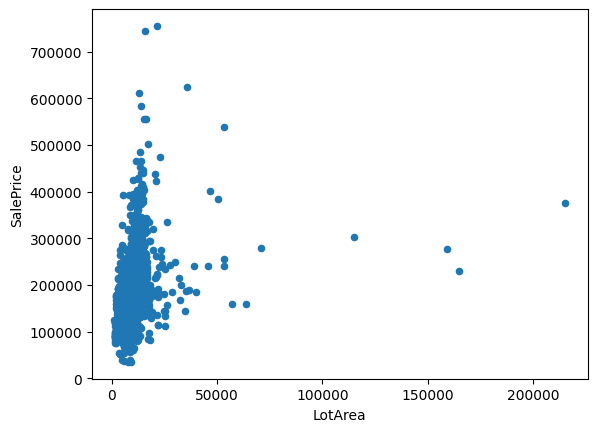

In [9]:
data = pd.concat([train_ds['LotArea'], train_ds['SalePrice']], axis = 1)
data.plot.scatter(x = 'LotArea', y = 'SalePrice')

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

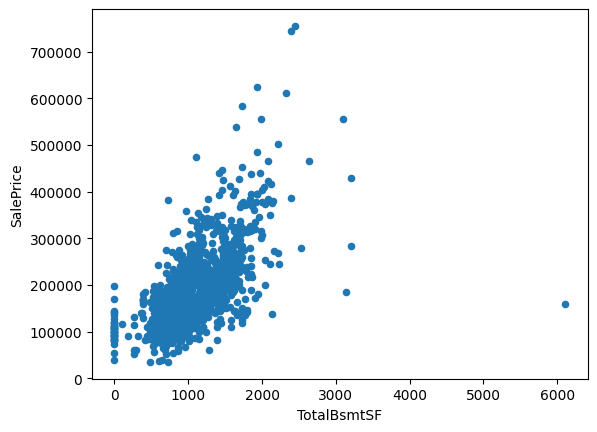

In [10]:
data = pd.concat([train_ds['TotalBsmtSF'], train_ds['SalePrice']], axis = 1)
data.plot.scatter(x = 'TotalBsmtSF', y = 'SalePrice')

<Axes: xlabel='GarageArea', ylabel='SalePrice'>

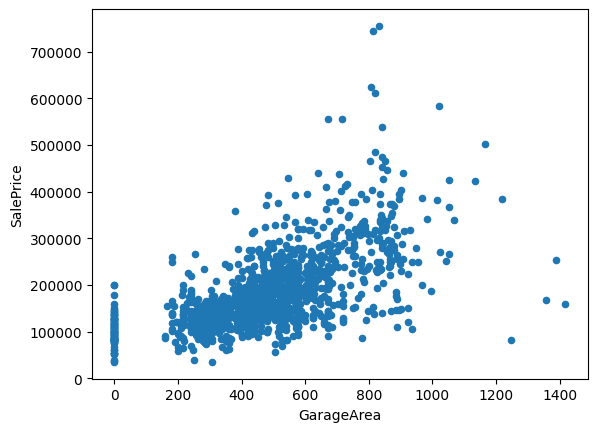

In [11]:
data = pd.concat([train_ds['GarageArea'], train_ds['SalePrice']], axis = 1)
data.plot.scatter(x = 'GarageArea', y = 'SalePrice')

<Axes: xlabel='MasVnrArea', ylabel='SalePrice'>

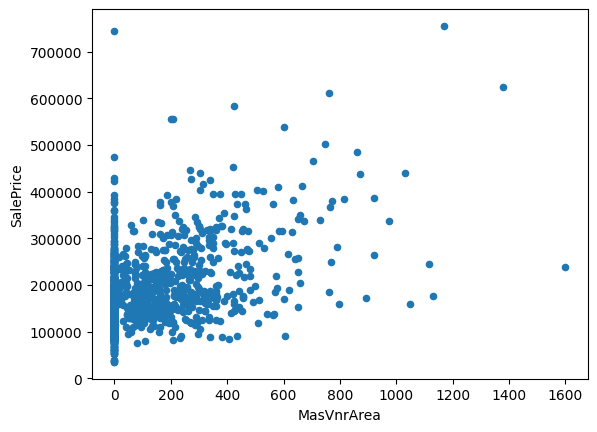

In [12]:
data = pd.concat([train_ds['MasVnrArea'], train_ds['SalePrice']], axis = 1)
data.plot.scatter(x = 'MasVnrArea', y = 'SalePrice')

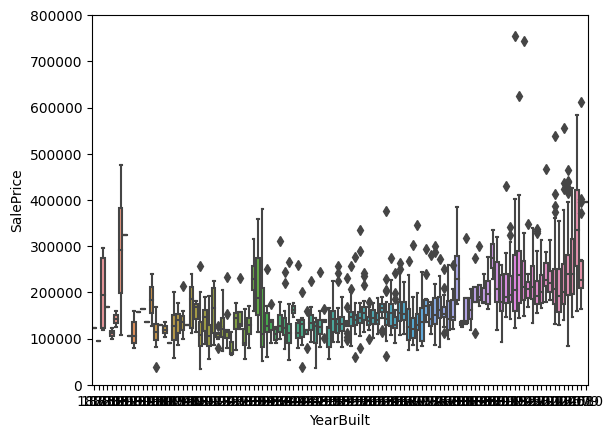

In [13]:
data = pd.concat([train_ds['YearBuilt'], train_ds['SalePrice']], axis = 1)
fig = sns.boxplot(x = 'YearBuilt', y = 'SalePrice', data = data)
fig.axis(ymin=0, ymax=800000);

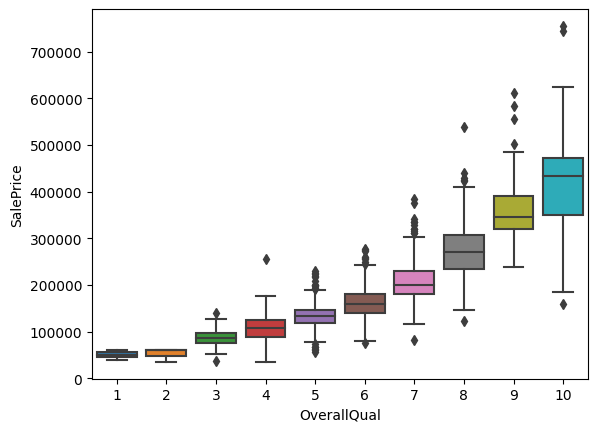

In [14]:
data = pd.concat([train_ds['OverallQual'], train_ds['SalePrice']], axis = 1)
fig = sns.boxplot(x = 'OverallQual', y = 'SalePrice', data = data)

In [15]:
#train_ds.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

## Data Preprocessing

In [16]:
train_ds.drop(['Id', 'MoSold', 'GarageYrBlt', 'Condition1', 'Condition2'], axis = 1, inplace = True)

In [17]:
for column in train_ds:
    null_count = train_ds[column].isnull().sum()
    if null_count > 1:
        print(f"Dropping column {column} with {null_count} missing values.")
        train_ds.drop(column, axis = 1, inplace = True)

Dropping column LotFrontage with 259 missing values.
Dropping column Alley with 1369 missing values.
Dropping column MasVnrType with 872 missing values.
Dropping column MasVnrArea with 8 missing values.
Dropping column BsmtQual with 37 missing values.
Dropping column BsmtCond with 37 missing values.
Dropping column BsmtExposure with 38 missing values.
Dropping column BsmtFinType1 with 37 missing values.
Dropping column BsmtFinType2 with 38 missing values.
Dropping column FireplaceQu with 690 missing values.
Dropping column GarageType with 81 missing values.
Dropping column GarageFinish with 81 missing values.
Dropping column GarageQual with 81 missing values.
Dropping column GarageCond with 81 missing values.
Dropping column PoolQC with 1453 missing values.
Dropping column Fence with 1179 missing values.
Dropping column MiscFeature with 1406 missing values.


In [18]:
le = LabelEncoder()
string_columns = train_ds.select_dtypes(include = ['object']).columns
for column in string_columns:
    train_ds[column] = le.fit_transform(train_ds[column])

In [19]:
train_ds.head(5)
#train_ds.shape

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,8450,1,3,3,0,4,0,5,...,61,0,0,0,0,0,2008,8,4,208500
1,20,3,9600,1,3,3,0,2,0,24,...,0,0,0,0,0,0,2007,8,4,181500
2,60,3,11250,1,0,3,0,4,0,5,...,42,0,0,0,0,0,2008,8,4,223500
3,70,3,9550,1,0,3,0,0,0,6,...,35,272,0,0,0,0,2006,8,0,140000
4,60,3,14260,1,0,3,0,2,0,15,...,84,0,0,0,0,0,2008,8,4,250000


## Training

In [20]:
X = train_ds.drop(['SalePrice'], axis = 1)
y = train_ds['SalePrice']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [22]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1022, 58)
(1022,)
(438, 58)
(438,)


### Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression
LR_Model = LinearRegression()

In [24]:
LR_Model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = LR_Model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [26]:
print(f'Mean Absolute Average: {mae}')
print(f'Mean Squared Average: {mse}')
print(f'R2 Score: {r2}')

Mean Absolute Average: 21989.139622466682
Mean Squared Average: 1117494613.7321186
R2 Score: 0.8398567499927523


### Simple Neural Network

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Input

In [28]:
model = keras.Sequential()

model.add(Input(shape = (58, )))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(16, activation = 'relu'))
model.add(Dense(1))

model.compile(optimizer = keras.optimizers.Adam(0.015), loss = 'mean_squared_error')

In [29]:
model.fit(X_train, y_train, epochs = 30, batch_size = 32)

Epoch 1/30
32/32 [==============================] - 1s 2ms/step - loss: 17590110208.0000
Epoch 2/30
32/32 [==============================] - 0s 1ms/step - loss: 5537102336.0000
Epoch 3/30
32/32 [==============================] - 0s 1ms/step - loss: 3608168448.0000
Epoch 4/30
32/32 [==============================] - 0s 1ms/step - loss: 3120843776.0000
Epoch 5/30
32/32 [==============================] - 0s 1ms/step - loss: 2877526528.0000
Epoch 6/30
32/32 [==============================] - 0s 1ms/step - loss: 2779983616.0000
Epoch 7/30
32/32 [==============================] - 0s 1ms/step - loss: 2522787840.0000
Epoch 8/30
32/32 [==============================] - 0s 1ms/step - loss: 2325529088.0000
Epoch 9/30
32/32 [==============================] - 0s 1ms/step - loss: 2293021184.0000
Epoch 10/30
32/32 [==============================] - 0s 1ms/step - loss: 2238888192.0000
Epoch 11/30
32/32 [==============================] - 0s 1ms/step - loss: 2223050496.0000
Epoch 12/30
32/32 [==========

In [30]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'MSE: {mse}')

14/14 [==============================] - 0s 906us/step
R2 Score: 0.758922438380979
MSE: 1682261828.6361516


### Decision trees

In [31]:
from sklearn.tree import DecisionTreeRegressor

reg = DecisionTreeRegressor()

In [32]:
reg.fit(X_train, y_train)

DecisionTreeRegressor()

In [33]:
y_pred = reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'MSE: {mse}')

R2 Score: 0.7727955936719467
MSE: 1585453650.2557077


### Random Forest Regressor

In [34]:
from sklearn.ensemble import RandomForestRegressor
FReg = RandomForestRegressor(n_estimators = 100, random_state = 42)

In [35]:
FReg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [36]:
y_pred = FReg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'MSE: {mse}')

R2 Score: 0.9044780066201905
MSE: 666561426.0361346


### XGBoost

In [37]:
from xgboost import XGBRegressor
XGB = XGBRegressor(n_estmators = 100, random_state = 42)

In [38]:
XGB.fit(X_train, y_train)

[06:50:53] WARNING: ../src/learner.cc:767: 
Parameters: { "n_estmators" } are not used.



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_estmators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, ...)

In [39]:
y_pred = XGB.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'MSE: {mse}')

R2 Score: 0.900488989463444
MSE: 694397161.7699064


## Graph for analyzing models

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Linear Regression'),
  Text(1, 0, 'Neural Network'),
  Text(2, 0, 'Decision Tree'),
  Text(3, 0, 'Random Forest'),
  Text(4, 0, 'XGBoost')])

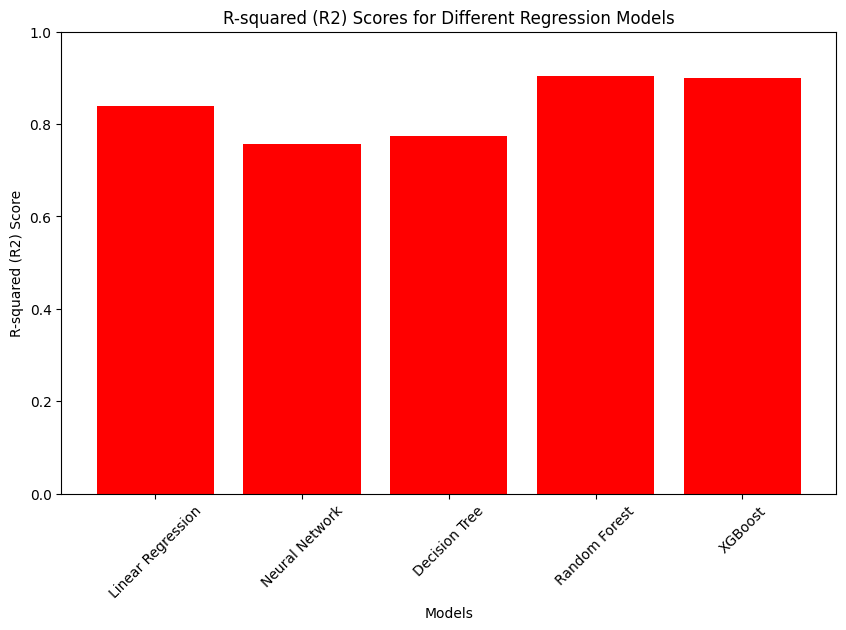

In [40]:
model_names = ['Linear Regression', 'Neural Network', 'Decision Tree', 'Random Forest', 'XGBoost']  

r2_scores = [0.83985, 0.75706, 0.77352, 0.90447, 0.90048]  


plt.figure(figsize=(10, 6))
plt.bar(model_names, r2_scores, color='red')
plt.xlabel('Models')
plt.ylabel('R-squared (R2) Score')
plt.title('R-squared (R2) Scores for Different Regression Models')
plt.ylim(0, 1) 
plt.xticks(rotation=45)

## Data Preprocessing Test Data


In [41]:
test_ds.drop(['Id', 'MoSold', 'GarageYrBlt', 'Condition1', 'Condition2'], axis = 1, inplace = True)

In [42]:
Null_Count = pd.DataFrame(train_ds.isnull().sum())
Null_Count

,0
MSSubClass,0
MSZoning,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0
LandSlope,0
Neighborhood,0


In [43]:
for column in test_ds:
    null_count = test_ds[column].isnull().sum()
    if null_count > 1:
        print(f"Dropping column {column} with {null_count} missing values.")
        test_ds.drop(column, axis = 1, inplace = True)

Dropping column MSZoning with 4 missing values.
Dropping column LotFrontage with 227 missing values.
Dropping column Alley with 1352 missing values.
Dropping column Utilities with 2 missing values.
Dropping column MasVnrType with 894 missing values.
Dropping column MasVnrArea with 15 missing values.
Dropping column BsmtQual with 44 missing values.
Dropping column BsmtCond with 45 missing values.
Dropping column BsmtExposure with 44 missing values.
Dropping column BsmtFinType1 with 42 missing values.
Dropping column BsmtFinType2 with 42 missing values.
Dropping column BsmtFullBath with 2 missing values.
Dropping column BsmtHalfBath with 2 missing values.
Dropping column Functional with 2 missing values.
Dropping column FireplaceQu with 730 missing values.
Dropping column GarageType with 76 missing values.
Dropping column GarageFinish with 78 missing values.
Dropping column GarageQual with 78 missing values.
Dropping column GarageCond with 78 missing values.
Dropping column PoolQC with 1

In [44]:
le = LabelEncoder()
string_columns = test_ds.select_dtypes(include = ['object']).columns
for column in string_columns:
    test_ds[column] = le.fit_transform(test_ds[column])

In [45]:
test_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 53 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   LotArea        1459 non-null   int64  
 2   Street         1459 non-null   int64  
 3   LotShape       1459 non-null   int64  
 4   LandContour    1459 non-null   int64  
 5   LotConfig      1459 non-null   int64  
 6   LandSlope      1459 non-null   int64  
 7   Neighborhood   1459 non-null   int64  
 8   BldgType       1459 non-null   int64  
 9   HouseStyle     1459 non-null   int64  
 10  OverallQual    1459 non-null   int64  
 11  OverallCond    1459 non-null   int64  
 12  YearBuilt      1459 non-null   int64  
 13  YearRemodAdd   1459 non-null   int64  
 14  RoofStyle      1459 non-null   int64  
 15  RoofMatl       1459 non-null   int64  
 16  Exterior1st    1459 non-null   int64  
 17  Exterior2nd    1459 non-null   int64  
 18  ExterQua

## RandomForest

In [46]:
predictions = FReg.predict(test_ds)
submissions_df = pd.DataFrame({
    "ID" : test_data['ID'],
    "Predictions" : predictions
})

submissions_df.to_csv('submission_csv', index = False)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- BsmtFullBath
- BsmtHalfBath
- Functional
- MSZoning
- Utilities
